# Beamline geometry and the material budget from the IP to the detector

Validation of `mint.beamline`: everything a forward neutrino has to cross on its
way out of the machine, and what that does to the neutrino, secondary-muon and
secondary-$\nu_\tau$ rates as a function of where the detector sits.

| region | material |
|---|---|
| $\|z\| < 180$ m | machine straight section: **vacuum bore inside a tungsten shielding tube** |
| $180 < z < 250$ m | tunnel air |
| $250\ \mathrm{m} < z < D - \mathrm{gap}$ | standard rock |
| last 10 m | air gap |
| $z > D$ | the detector (HPGAr + 3 W slabs) |

The shielding follows **MuCol Milestone 15** (Calzolari & Vanwelde 2024,
DOI 10.5281/zenodo.14000854) Sec. 2.2 / Table 1: a round vacuum aperture of
radius $\max(5\sigma)$ wrapped in 2.53 cm of tungsten (4.5 cm for the chicane
dipoles). The report does not quote a thickness for the drift sections
("in the drift sections, the beam pipe is surrounded by a tungsten shielding"),
so the quadrupole value is used there; and the $5\sigma$ envelope collapses to
microns at the beam waists, so a **minimum aperture radius of 2 cm is assumed**.
Both assumptions are stress-tested in Sec. 3.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../physics-examples"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm

import mint
from mint import detector_tools as dt
from mint import xsecs, plot_tools as pt

plt.rcParams.update({"figure.dpi": 110})
rng = np.random.default_rng(4)

ring = mint.lattices.load("mc_10tev_hybrid_v06")
det  = mint.detectors.load("benchmark_5km")
bl   = mint.beamline.Beamline(det, lattice=ring)

DET_R, GAP = det.radius, det.gap
DET_L = det.fiducial_length
print(det)
print(bl)
print(bl.shield)
print(f"rock starts at {det.rock_start/100:.0f} m, straight section ends at "
      f"{bl.straight_half_length/100:.0f} m")

ForwardDetector('hpgar_5km': 10 m x 4 m gas + 3x5 cm slabs at 5 km, 10 m gap)
Beamline(straight |z|<180 m, rock from 250 m, det at 5.00 km)
StraightSectionShield(|z| < 180 m, 36 segments, aperture 2.0-10.3 cm, wall 2.53-4.50 cm W)
rock starts at 250 m, straight section ends at 180 m


## 1. The shielding geometry

Per-segment aperture $=5\,\max(\sigma_x,\sigma_y)$ from the packaged 10 TeV
lattice, floored at 2 cm. The chicane is located automatically from the
closed-orbit excursion and given the thicker dipole wall.

  k   z0[m]   z1[m]  r_in[cm]  wall[cm]  r_out[cm]
  0     6.0    10.8      3.66      2.53       6.19
  3    20.5    25.3     10.26      2.53      12.79
  6    35.0    39.8      8.51      2.53      11.04
  9    49.5    54.3      7.83      4.50      12.33
 12    64.0    68.8      6.59      2.53       9.12
 15    78.5    83.3      5.35      2.53       7.88
 18    93.0    97.8      4.11      2.53       6.64
 21   107.5   112.3      2.91      2.53       5.44
 24   122.0   126.8      2.32      2.53       4.85
 27   136.5   141.3      2.00      2.53       4.53
 30   151.0   155.8      2.00      2.53       4.53
 33   165.5   170.3      2.20      2.53       4.73

chicane span (auto-detected): [44.66666667 64.        ] m
aperture range: 2.00 - 10.26 cm
MuCol Table 2 inner COIL radii for the IR magnets: 7 - 16 cm (ours is the vacuum bore + wall = 4.5 - 12.8 cm)


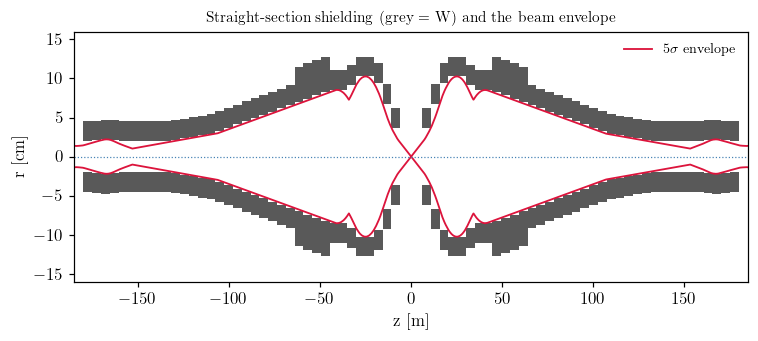

In [3]:
sh = bl.shield
print(f"{'k':>3} {'z0[m]':>7} {'z1[m]':>7} {'r_in[cm]':>9} {'wall[cm]':>9} {'r_out[cm]':>10}")
for k in range(0, len(sh.r_in), 3):
    print(f"{k:3d} {sh.edges[k]/100:7.1f} {sh.edges[k+1]/100:7.1f} "
          f"{sh.r_in[k]:9.2f} {sh.t_wall[k]:9.2f} {sh.r_out[k]:10.2f}")
print(f"\nchicane span (auto-detected): {np.array(sh.chicane_span)/100} m")
print(f"aperture range: {sh.r_in.min():.2f} - {sh.r_in.max():.2f} cm")
print(f"MuCol Table 2 inner COIL radii for the IR magnets: 7 - 16 cm "
      f"(ours is the vacuum bore + wall = {sh.r_out.min():.1f} - {sh.r_out.max():.1f} cm)")

fig, ax = plt.subplots(figsize=(7, 3.2))
for k in range(len(sh.r_in)):
    z0, z1 = sh.edges[k]/100, sh.edges[k+1]/100
    for s in (+1, -1):
        ax.add_patch(Rectangle((s*z0 if s > 0 else -z1, sh.r_in[k]), z1-z0,
                               sh.t_wall[k], facecolor="0.35", edgecolor="none"))
        ax.add_patch(Rectangle((s*z0 if s > 0 else -z1, -sh.r_out[k]), z1-z0,
                               sh.t_wall[k], facecolor="0.35", edgecolor="none"))
u = np.linspace(0, 1, 40001)
s_ = np.asarray(ring.s(u)); x_ = np.asarray(ring.x(u)); y_ = np.asarray(ring.y(u))
z_ = np.asarray(ring.z(u))
i0 = int(np.argmin(x_**2 + y_**2 + z_**2)); dz = (s_ - s_[i0])/100
env = 5*np.maximum(ring.beamsize_x(u), ring.beamsize_y(u))
m = np.abs(dz) <= 185
ax.plot(dz[m], env[m], color="crimson", lw=1.2, label=r"$5\sigma$ envelope")
ax.plot(dz[m], -env[m], color="crimson", lw=1.2)
ax.axhline(0, color="steelblue", lw=0.8, ls=":")
ax.set_xlim(-185, 185); ax.set_ylim(-16, 16)
ax.set_xlabel("z [m]"); ax.set_ylabel("r [cm]")
ax.set_title("Straight-section shielding (grey = W) and the beam envelope", fontsize=10)
ax.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout()

## 2. Density map of the whole problem

`Beamline.density_map` on a $(z, r)$ grid. Note the log $z$ axis: the
straight section, the rock and the detector differ by three orders of
magnitude in scale.

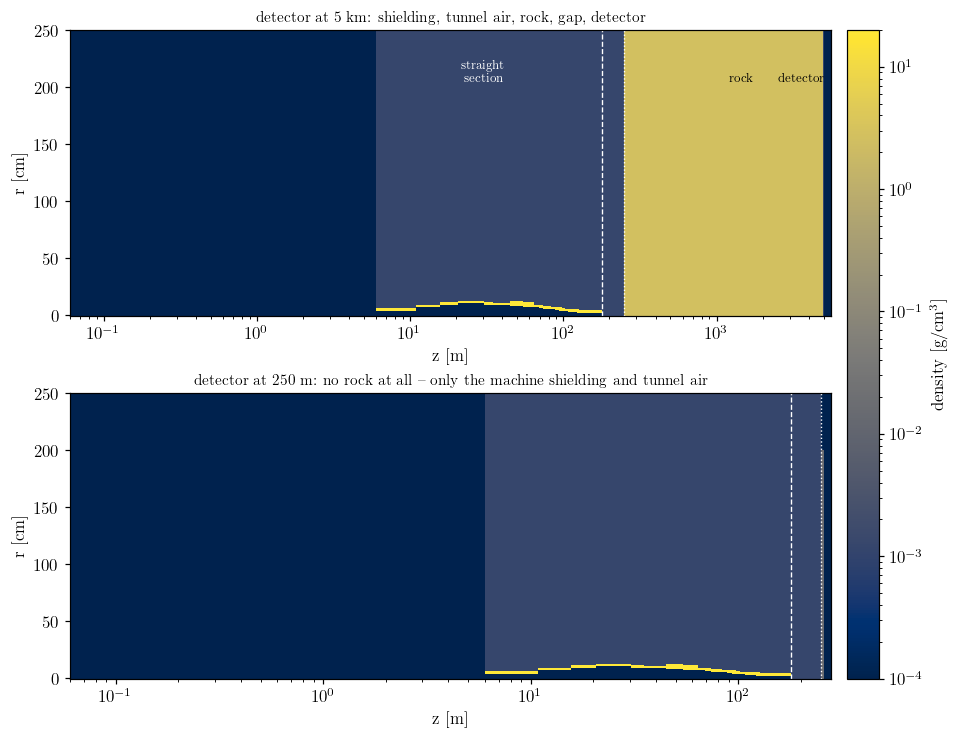

In [4]:
def draw_density(dist, ax, zlim=None, rlim=60.0, nz=1400, nr=420, log_z=True):
    z_hi = zlim if zlim is not None else dist + det.length*1.4
    zg = (np.geomspace(6.0, z_hi, nz) if log_z else np.linspace(0.0, z_hi, nz))
    rg = np.linspace(0.0, rlim, nr)
    rho = bl.density_map(zg, rg, dist=dist)
    pc = ax.pcolormesh(zg/100, rg, np.maximum(rho, 1e-5), shading="auto",
                       norm=LogNorm(vmin=1e-4, vmax=20.0), cmap="cividis")
    if log_z: ax.set_xscale("log")
    ax.set_xlabel("z [m]"); ax.set_ylabel("r [cm]")
    return pc

fig, axes = plt.subplots(2, 1, figsize=(8.6, 6.6), constrained_layout=True)
pc = draw_density(5e5, axes[0], zlim=5.6e5, rlim=250)
axes[0].set_title("detector at 5 km: shielding, tunnel air, rock, gap, detector",
                  fontsize=10)
pc = draw_density(250e2, axes[1], zlim=2.8e4, rlim=250)
axes[1].set_title("detector at 250 m: no rock at all -- only the machine "
                  "shielding and tunnel air", fontsize=10)
for ax in axes:
    ax.axvline(bl.straight_half_length/100, color="w", lw=0.9, ls="--")
    ax.axvline(det.rock_start/100, color="w", lw=0.9, ls=":")
axes[0].annotate("straight\nsection", xy=(30, 205), color="w", fontsize=8, ha="center")
axes[0].annotate("rock", xy=(1200, 205), color="k", fontsize=8)
axes[0].annotate("detector", xy=(5000, 205), color="k", fontsize=8, ha="right")
fig.colorbar(pc, ax=axes, label=r"density [g/cm$^3$]", pad=0.02)
fig.savefig("../plots/beamline_density_map.pdf", bbox_inches="tight", dpi=300)

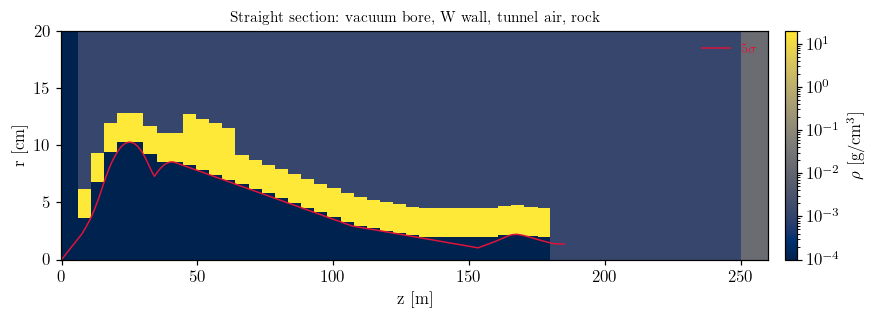

In [5]:
# zoom on the straight section: the tungsten tube and its tapering bore
fig, ax = plt.subplots(figsize=(8.5, 3.0))
zg = np.linspace(0.0, 260e2, 1600); rg = np.linspace(0.0, 20.0, 400)
rho = bl.density_map(zg, rg, dist=250e2)
pc = ax.pcolormesh(zg/100, rg, np.maximum(rho, 1e-5), shading="auto",
                   norm=LogNorm(vmin=1e-4, vmax=20.0), cmap="cividis")
ax.plot(dz[m][dz[m] >= 0], env[m][dz[m] >= 0], color="crimson", lw=1.0,
        label=r"$5\sigma$")
ax.set_xlabel("z [m]"); ax.set_ylabel("r [cm]"); ax.set_ylim(0, 20)
ax.legend(frameon=False, fontsize=9, loc="upper right", labelcolor="crimson")
ax.set_title("Straight section: vacuum bore, W wall, tunnel air, rock", fontsize=10)
fig.colorbar(pc, ax=ax, label=r"$\rho$ [g/cm$^3$]", pad=0.02)
plt.tight_layout()

## 3. Validation of the tube geometry

Analytic closure of `TubeVolume`, convergence in the number of segments, and
the sensitivity to the two assumptions (drift-section wall thickness and the
minimum aperture).

In [6]:
tube = dt.TubeVolume(dt.W, r_in=2.0, r_out=4.0, length=100.0, center=(0,0,50.0))
o = np.array([[0.],[0.],[0.]])
checks = [
  ("axial down the bore",        np.array([[0.],[0.],[1.]]), o,                       0.0),
  ("axial inside the wall",      np.array([[0.],[0.],[1.]]), np.array([[3.],[0.],[0.]]), 100.0),
  ("transverse through centre",  np.array([[1.],[0.],[0.]]), np.array([[-10.],[0.],[50.]]), 4.0),
  ("transverse miss (r>r_out)",  np.array([[1.],[0.],[0.]]), np.array([[-10.],[5.],[50.]]), 0.0),
  ("transverse at b=3",          np.array([[1.],[0.],[0.]]), np.array([[-10.],[3.],[50.]]), 2*np.sqrt(7)),
]
print(f"{'case':28s} {'chord':>10} {'expected':>10}   ok")
for name, d, oo, exp in checks:
    got = float(tube.intersect(oo, d)[1][0])
    print(f"{name:28s} {got:10.5f} {exp:10.5f}   {np.isclose(got, exp)}")
th_ = 0.05
got = float(tube.intersect(o, np.array([[np.sin(th_)],[0.],[np.cos(th_)]]))[1][0])
print(f"{'small-angle from origin':28s} {got:10.5f} {(4-2)/np.sin(th_):10.5f}   "
      f"{np.isclose(got, (4-2)/np.sin(th_))}")

case                              chord   expected   ok
axial down the bore             0.00000    0.00000   True
axial inside the wall         100.00000  100.00000   True
transverse through centre       4.00000    4.00000   True
transverse miss (r>r_out)       0.00000    0.00000   True
transverse at b=3               5.29150    5.29150   True
small-angle from origin        40.01667   40.01667   True


In [7]:
ths = np.array([1e-4, 2e-4, 4e-4, 8e-4])
o0 = np.zeros((3, ths.size)); d0 = np.array([np.sin(ths), np.zeros_like(ths), np.cos(ths)])
print("W path [m] for a ray leaving the IP -- convergence in segmentation")
print("  nseg |" + "".join(f"{t*1e6:9.0f} ur" for t in ths))
for n in (9, 18, 36, 72, 144, 288):
    s_ = mint.beamline.StraightSectionShield(lattice=ring, n_segments=n)
    print(f"  {n:4d} |" + "".join(f"{c/100:12.2f}" for c in s_.chord(o0, d0)))

print("\nsensitivity to the two ASSUMPTIONS")
print("  min aperture [cm] |" + "".join(f"{t*1e6:9.0f} ur" for t in ths))
for rmin in (1.0, 2.0, 3.0, 5.0):
    s_ = mint.beamline.StraightSectionShield(lattice=ring, min_aperture=rmin)
    print(f"  {rmin:17.1f} |" + "".join(f"{c/100:12.2f}" for c in s_.chord(o0, d0)))
print("  drift wall [cm]   |" + "".join(f"{t*1e6:9.0f} ur" for t in ths))
for tw in (1.0, 2.53, 4.5):
    s_ = mint.beamline.StraightSectionShield(lattice=ring, thickness=tw)
    print(f"  {tw:17.2f} |" + "".join(f"{c/100:12.2f}" for c in s_.chord(o0, d0)))

W path [m] for a ray leaving the IP -- convergence in segmentation
  nseg |      100 ur      200 ur      400 ur      800 ur
     9 |        0.00       58.00       19.33       10.99
    18 |        0.00       58.00       19.33       19.33
    36 |        0.00       58.00       24.17       14.54
    72 |        0.00       59.09       24.31       14.54
   144 |        0.00       59.21       25.38       14.86
   288 |        0.00       59.81       25.44       15.14

sensitivity to the two ASSUMPTIONS
  min aperture [cm] |      100 ur      200 ur      400 ur      800 ur
                1.0 |       14.24       58.00       24.17       14.54


                2.0 |        0.00       58.00       24.17       14.54


                3.0 |        0.00       30.00       40.42       14.54
                5.0 |        0.00        0.00       55.00       20.46
  drift wall [cm]   |      100 ur      200 ur      400 ur      800 ur
               1.00 |        0.00       28.00        9.38        5.73
               2.53 |        0.00       58.00       24.17       14.54
               4.50 |        0.00       58.00       69.76       28.85


## 4. The beam simulation, with the $5\sigma$ collimation

`MuDecaySimulator` now truncates the transverse beam envelope at the physical
aperture (`aperture_nsigma=5`). A 2D Gaussian truncated at $5\sigma$ keeps
$1-e^{-25/2} = 1 - 3.7\times10^{-6}$ of the beam, so this is a per-million
correction to the flux -- but it is the surface the shielding bore is cut on,
so the two are now consistent.

In [8]:
ring, sims, ipy = mint.examples.both_beams(n_evals=3e5)
print("flavors:", list(sims), f"\ninjections/yr = {ipy:.3e}")

# What the 5 sigma cut removes. NOTE pos["x"], pos["y"] are WORLD coordinates
# and are dominated by where the decay sits around the ring, so the envelope
# offset has to be measured against the closed orbit, not as |r|.
def envelope_offset(s):
    u = s.u_parameter if hasattr(s, "u_parameter") else None
    return None
_, sim_free, _ = mint.examples.standard_beam(n_evals=3e5, ring=ring)
sim_free.aperture_nsigma = None
sim_free.place_muons_on_lattice(lattice=ring, direction="clockwise")

# the truncation is exact and analytic; verify the sampler and its effect on
# the observable that matters -- the flux through the face at 5 km
for nm, s in (("5 sigma (default)", sims["numubar"]), ("untruncated", sim_free)):
    E_, w_ = det.face_flux(s, exposure=ipy, dist=5e5)
    print(f"  {nm:18s}: flux through the 5 km face = {w_.sum():.6e} nu/yr "
          f"({E_.size} MC rays)")
print(f"\n  a 2D Gaussian truncated at 5 sigma keeps 1 - exp(-25/2) = "
      f"1 - {np.exp(-12.5):.3e} of the beam,")
print(f"  so the flux may only differ at the ppm level (MC noise here is larger).")

/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


flavors: ['numubar', 'nue', 'numu', 'nuebar'] 
injections/yr = 5.023e+07


  5 sigma (default) : flux through the 5 km face = 2.207938e+18 nu/yr (49706 MC rays)
  untruncated       : flux through the 5 km face = 2.214906e+18 nu/yr (49420 MC rays)

  a 2D Gaussian truncated at 5 sigma keeps 1 - exp(-25/2) = 1 - 3.727e-06 of the beam,
  so the flux may only differ at the ppm level (MC noise here is larger).


   D [m]     W column  bulk column   W frac         X_W      X_bulk
     250   2.1693e+28   5.1622e+24   99.98%  3.5992e+04  8.5750e+00
     328   2.4505e+28   1.0899e+28   69.22%  4.0656e+04  1.8098e+04
     431   2.4984e+28   2.7297e+28   47.79%  4.1451e+04  4.5328e+04
     566   2.5220e+28   4.8829e+28   34.06%  4.1843e+04  8.1083e+04
     743   2.5603e+28   7.7101e+28   24.93%  4.2478e+04  1.2803e+05
     976   2.6238e+28   1.1422e+29   18.68%  4.3531e+04  1.8967e+05
    1281   2.6771e+28   1.6296e+29   14.11%  4.4416e+04  2.7061e+05
    1682   2.7194e+28   2.2696e+29   10.70%  4.5117e+04  3.7688e+05
    2209   2.7615e+28   3.1100e+29    8.16%  4.5817e+04  5.1642e+05
    2900   2.7748e+28   4.2134e+29    6.18%  4.6037e+04  6.9965e+05
    3808   2.7808e+28   5.6622e+29    4.68%  4.6136e+04  9.4022e+05
    5000   2.7700e+28   7.5645e+29    3.53%  4.5957e+04  1.2561e+06


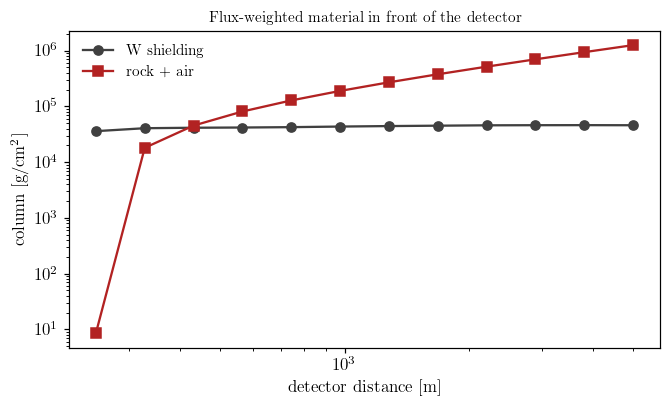

In [9]:
# flux-weighted tungsten column seen by the neutrinos that reach the face
sim = sims["numubar"]
DIST_SCAN = np.geomspace(250e2, 5e5, 12)
rows = []
for D in DIST_SCAN:
    p = bl.flux_weighted_profile(sim, dist=D, exposure=ipy, sign=+1)
    L = p["z1"] - p["z0"]
    isW = np.array(["shield" in n for n in p["names"]])
    rows.append(dict(D=D, colW=float((p["n_nuc"]*L)[isW].sum()),
                     colB=float((p["n_nuc"]*L)[~isW].sum()),
                     XW=float((p["rho"]*L)[isW].sum()),
                     XB=float((p["rho"]*L)[~isW].sum()), flux=p["flux"]))
print(f"{'D [m]':>8} {'W column':>12} {'bulk column':>12} {'W frac':>8} "
      f"{'X_W':>11} {'X_bulk':>11}")
for r_ in rows:
    tot = r_['colW'] + r_['colB']
    print(f"{r_['D']/100:8.0f} {r_['colW']:12.4e} {r_['colB']:12.4e} "
          f"{r_['colW']/tot:8.2%} {r_['XW']:11.4e} {r_['XB']:11.4e}")

fig, ax = plt.subplots(figsize=(6.2, 3.8))
Ds = np.array([r_["D"] for r_ in rows])/100
ax.plot(Ds, [r_["XW"] for r_ in rows], "o-", color="0.25", label="W shielding")
ax.plot(Ds, [r_["XB"] for r_ in rows], "s-", color="firebrick", label="rock + air")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("detector distance [m]"); ax.set_ylabel(r"column [g/cm$^2$]")
ax.set_title("Flux-weighted material in front of the detector", fontsize=10)
ax.legend(frameon=False); plt.tight_layout()
fig.savefig("../plots/beamline_columns.pdf", bbox_inches="tight", dpi=300)

## 5. Milestone 1 --- neutrino interaction rate vs detector location

Total SM neutrino interactions per year in the benchmark detector (10 m HPGAr
+ 3 tungsten slabs, 2 m radius) as its front face is moved from 250 m to 5 km,
**including the geometric acceptance**: the face subtends
$\pi R^2/D^2$, so the rate falls steeply with distance while the detector
composition stays fixed.

In [10]:
SIGN = {fl: (+1 if fl in mint.examples.MU_PLUS_FLAVORS else -1) for fl in sims}
print("detector side per flavor (mu+ beam -> +z, mu- beam -> -z):", SIGN)

def interactions_at(D, sim, nuflavor, sign=+1):
    # total CC+NC interactions/yr in the gas + W slabs, face at D
    origin, direction = dt.sim_rays(sim)
    if sign < 0:
        origin = (origin[0], origin[1], -origin[2])
        direction = (direction[0], direction[1], -direction[2])
    gas_vol = dt.CylinderVolume(det.gas, radius=DET_R, length=DET_L,
                                center=(0, 0, D + DET_L/2))
    _, ch = gas_vol.intersect(origin, direction)
    column = det.gas.N * ch
    for z0, thick, mat in det.targets:
        slab = dt.CylinderVolume(mat, radius=DET_R, length=thick,
                                 center=(0, 0, D + z0 + thick/2))
        _, chs = slab.intersect(origin, direction)
        column = column + mat.N * chs
    E = np.asarray(sim.pnu["E"]); w = sim.weights.flatten() * ipy
    m = (column > 0) & (E > 5.0)
    sig = np.clip(xsecs.total_xsecs[nuflavor](E[m]), 0.0, None)
    return float(np.sum(w[m] * -np.expm1(-sig * column[m])))

face_flux = {}
for fl, s_ in sims.items():
    face_flux[fl] = np.array([det.face_flux(s_, exposure=ipy, dist=D,
                                            sign=SIGN[fl])[1].sum()
                              for D in DIST_SCAN])
ff = sum(face_flux.values())
print("flux through the face [nu/yr]:")
for i, D in enumerate(DIST_SCAN):
    print(f"  {D/100:8.0f} m  {ff[i]:.4e}   (relative to 250 m: {ff[i]/ff[0]:.3f})")

scan = {}
for fl, s in sims.items():
    scan[fl] = np.array([interactions_at(D, s, fl, sign=SIGN[fl]) for D in DIST_SCAN])
tot = sum(scan.values())
print(f"{'D [m]':>8} " + " ".join(f"{fl:>12}" for fl in scan) + f" {'TOTAL':>12}")
for i, D in enumerate(DIST_SCAN):
    print(f"{D/100:8.0f} " + " ".join(f"{scan[fl][i]:12.4e}" for fl in scan)
          + f" {tot[i]:12.4e}")

detector side per flavor (mu+ beam -> +z, mu- beam -> -z): {'numubar': 1, 'nue': 1, 'numu': -1, 'nuebar': -1}


flux through the face [nu/yr]:
       250 m  1.5086e+19   (relative to 250 m: 1.000)
       328 m  1.3325e+19   (relative to 250 m: 0.883)
       431 m  1.3064e+19   (relative to 250 m: 0.866)
       566 m  1.2930e+19   (relative to 250 m: 0.857)
       743 m  1.2682e+19   (relative to 250 m: 0.841)
       976 m  1.2222e+19   (relative to 250 m: 0.810)
      1281 m  1.1767e+19   (relative to 250 m: 0.780)
      1682 m  1.1245e+19   (relative to 250 m: 0.745)
      2209 m  1.0645e+19   (relative to 250 m: 0.706)
      2900 m  1.0037e+19   (relative to 250 m: 0.665)
      3808 m  9.4871e+18   (relative to 250 m: 0.629)
      5000 m  8.8575e+18   (relative to 250 m: 0.587)


   D [m]      numubar          nue         numu       nuebar        TOTAL
     250   6.0859e+09   8.7211e+09   1.0117e+10   5.2444e+09   3.0169e+10
     328   5.4263e+09   7.7612e+09   9.0018e+09   4.6763e+09   2.6866e+10
     431   5.3190e+09   7.6228e+09   8.8320e+09   4.5865e+09   2.6360e+10
     566   5.2662e+09   7.5438e+09   8.7374e+09   4.5440e+09   2.6091e+10
     743   5.1598e+09   7.3972e+09   8.5633e+09   4.4573e+09   2.5578e+10
     976   4.9843e+09   7.1336e+09   8.2491e+09   4.2994e+09   2.4666e+10
    1281   4.7931e+09   6.8700e+09   7.9177e+09   4.1487e+09   2.3729e+10
    1682   4.5850e+09   6.5751e+09   7.5703e+09   3.9638e+09   2.2694e+10
    2209   4.3440e+09   6.2241e+09   7.1826e+09   3.7519e+09   2.1503e+10
    2900   4.0961e+09   5.8789e+09   6.7699e+09   3.5320e+09   2.0277e+10
    3808   3.8657e+09   5.5638e+09   6.4231e+09   3.3473e+09   1.9200e+10
    5000   3.6127e+09   5.2048e+09   6.0249e+09   3.1312e+09   1.7974e+10


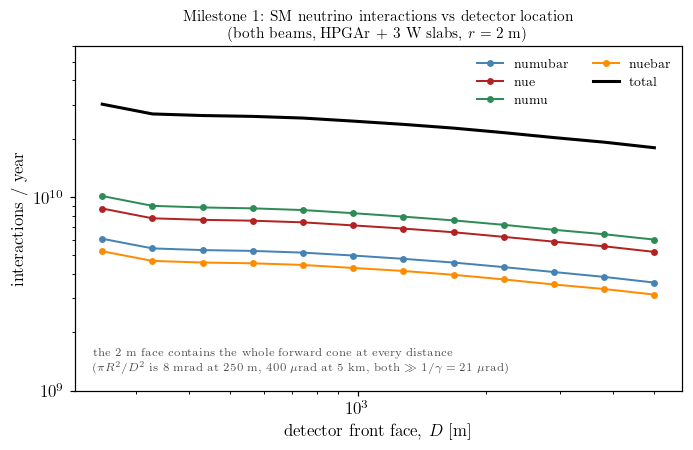

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
cols = {"numubar": "steelblue", "nue": "firebrick",
        "numu": "seagreen", "nuebar": "darkorange"}
for fl in scan:
    ax.plot(DIST_SCAN/100, scan[fl], "o-", ms=3.5, lw=1.3,
            color=cols.get(fl, "k"), label=fl)
ax.plot(DIST_SCAN/100, tot, "k-", lw=2.0, label="total")
ax.set_ylim(1e9, 6e10)
ax.annotate("the 2 m face contains the whole forward cone at every distance\n"
            r"($\pi R^2/D^2$ is 8 mrad at 250 m, 400 $\mu$rad at 5 km, both "
            r"$\gg 1/\gamma = 21\ \mu$rad)",
            xy=(0.03, 0.06), xycoords="axes fraction", fontsize=7.5, color="0.3")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("detector front face, $D$ [m]")
ax.set_ylabel("interactions / year")
ax.set_title("Milestone 1: SM neutrino interactions vs detector location\n"
             "(both beams, HPGAr + 3 W slabs, $r=2$ m)", fontsize=10)
ax.legend(frameon=False, fontsize=8.5, ncol=2)
plt.tight_layout()
fig.savefig("../plots/beamline_nu_rate_vs_distance.pdf", bbox_inches="tight", dpi=300)

**Reading the plot --- the rate is almost flat, and that is the point.**
Moving the detector from 250 m to 5 km, a factor 20 in distance, costs only a
factor $\sim$1.7 in interactions. There is no $1/D^2$ here: a 2 m radius face
subtends 8 mrad at 250 m and still 400 $\mu$rad at 5 km, both far wider than the
$1/\gamma = 21\ \mu$rad muon-decay cone, so the detector intercepts essentially
the *whole* forward flux at every distance in this range. What sets the rate is
the number of decays pointing at the detector, not the solid angle; the residual
decline is the wide-angle tail of the decay distribution gradually spilling
outside the face.

The practical consequence is that **the detector location is set by backgrounds
and by the upstream material, not by the neutrino rate** --- which is exactly
what Milestones 2 and 3 quantify.

## 6. Milestone 2 --- secondary muon flux vs detector location

Muons from $\nu$ CC interactions upstream, now produced anywhere in the
material profile: the tungsten shielding, the tunnel air and the rock. At
250 m there is **no rock at all** -- every secondary muon comes from the
machine shielding.

First a regression check: with the face at 5 km, where the profile is
overwhelmingly rock, the new profile-aware MC must reproduce the original
rock-only calculation.

In [12]:
import muon_beam as mb

def muon_flux_at(D, sim, nuflavor, n_mc=40_000, seed=7, sign=+1):
    E, w, rx, ry, sx, sy = det.face_rays(sim, exposure=ipy, dist=D, E_min=5.0,
                                         sign=sign)
    if E.size == 0:
        return None
    p = bl.flux_weighted_profile(sim, dist=D, exposure=ipy, E_min=5.0, sign=sign)
    out = mb.muon_beam_profile_mc(E, w, rx, ry, sx, sy, nuflavor,
                                  np.random.default_rng(seed), p, dist=D,
                                  det_r=DET_R, n_mc=n_mc)
    acc = np.hypot(out["srv_x"], out["srv_y"]) < DET_R
    return dict(rate=float(out["srv_w"][acc].sum()),
                E=out["srv_E"][acc], w=out["srv_w"][acc],
                z=out["srv_z"][acc] if "srv_z" in out else None)

# --- regression: profile-aware vs the original rock-only MC at 5 km ---
E5, w5, rx5, ry5, sx5, sy5 = det.face_rays(sims["numubar"], exposure=ipy,
                                           dist=5e5, E_min=5.0)
old = mb.muon_beam_mc(E5, w5, rx5, ry5, sx5, sy5, "numubar",
                      np.random.default_rng(7), l_prop_cm=2.5e5, gap_cm=GAP,
                      det_r=DET_R, n_mc=40_000)
acc_o = np.hypot(old["srv_x"], old["srv_y"]) < DET_R
new = muon_flux_at(5e5, sims["numubar"], "numubar", n_mc=40_000)
print(f"5 km, numubar:  rock-only MC = {old['srv_w'][acc_o].sum():.4e} mu/yr")
print(f"                profile   MC = {new['rate']:.4e} mu/yr")
print(f"                ratio         = {new['rate']/old['srv_w'][acc_o].sum():.4f}")

5 km, numubar:  rock-only MC = 1.0411e+12 mu/yr
                profile   MC = 1.0642e+12 mu/yr
                ratio         = 1.0223


In [13]:
mu_scan = {}
for fl in ("numubar", "numu"):
    mu_scan[fl] = []
    for D in DIST_SCAN:
        r_ = muon_flux_at(D, sims[fl], fl, sign=SIGN[fl])
        mu_scan[fl].append(r_["rate"] if r_ else 0.0)
    mu_scan[fl] = np.array(mu_scan[fl])
mu_tot = sum(mu_scan.values())
print(f"{'D [m]':>8} {'numubar':>13} {'numu':>13} {'total':>13} {'per cm2/yr':>13}")
for i, D in enumerate(DIST_SCAN):
    print(f"{D/100:8.0f} {mu_scan['numubar'][i]:13.4e} {mu_scan['numu'][i]:13.4e} "
          f"{mu_tot[i]:13.4e} {mu_tot[i]/(np.pi*DET_R**2):13.4e}")

   D [m]       numubar          numu         total    per cm2/yr
     250    4.6647e+11    6.2312e+11    1.0896e+12    8.6707e+06
     328    6.3870e+11    8.5910e+11    1.4978e+12    1.1919e+07
     431    8.5480e+11    1.1351e+12    1.9899e+12    1.5835e+07
     566    1.0620e+12    1.3753e+12    2.4374e+12    1.9396e+07
     743    1.2250e+12    1.5246e+12    2.7496e+12    2.1881e+07
     976    1.3305e+12    1.6172e+12    2.9477e+12    2.3457e+07
    1281    1.3708e+12    1.6568e+12    3.0275e+12    2.4092e+07
    1682    1.3667e+12    1.6187e+12    2.9854e+12    2.3757e+07
    2209    1.3005e+12    1.5408e+12    2.8413e+12    2.2611e+07
    2900    1.2331e+12    1.4551e+12    2.6882e+12    2.1392e+07
    3808    1.1395e+12    1.3441e+12    2.4836e+12    1.9764e+07
    5000    1.0589e+12    1.2474e+12    2.3063e+12    1.8353e+07


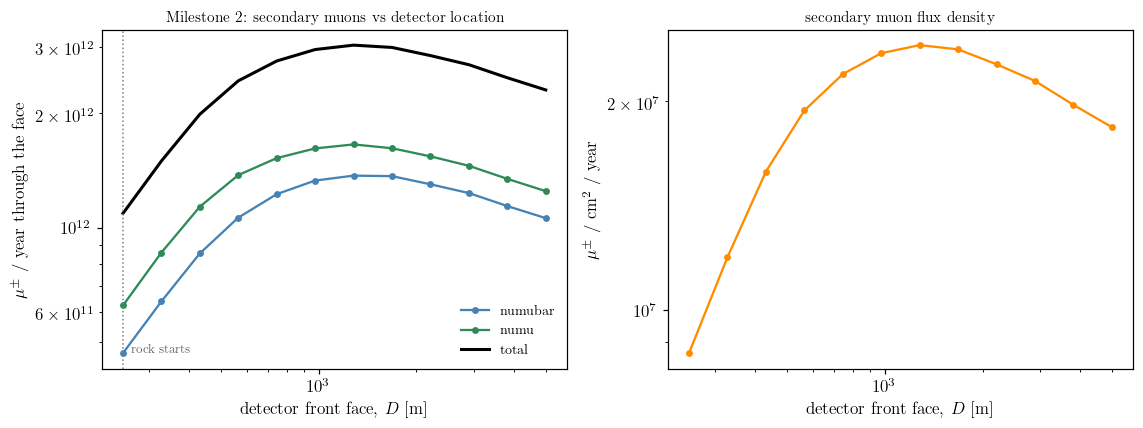

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.0))
for fl, c in (("numubar", "steelblue"), ("numu", "seagreen")):
    ax[0].plot(DIST_SCAN/100, mu_scan[fl], "o-", ms=3.5, color=c, label=fl)
ax[0].plot(DIST_SCAN/100, mu_tot, "k-", lw=2, label="total")
ax[0].axvline(det.rock_start/100, color="0.5", ls=":", lw=1)
ax[0].annotate("rock starts", xy=(det.rock_start/100*1.06, 0.05),
               xycoords=("data", "axes fraction"), fontsize=8, color="0.4")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("detector front face, $D$ [m]")
ax[0].set_ylabel(r"$\mu^\pm$ / year through the face")
ax[0].set_title("Milestone 2: secondary muons vs detector location", fontsize=10)
ax[0].legend(frameon=False, fontsize=9)

ax[1].plot(DIST_SCAN/100, mu_tot/(np.pi*DET_R**2), "o-", color="darkorange", ms=3.5)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("detector front face, $D$ [m]")
ax[1].set_ylabel(r"$\mu^\pm$ / cm$^2$ / year")
ax[1].set_title("secondary muon flux density", fontsize=10)
plt.tight_layout()
fig.savefig("../plots/beamline_muon_vs_distance.pdf", bbox_inches="tight", dpi=300)

## 7. Milestone 3 --- secondary $\nu_\tau$ rate vs detector location

Charmed-meson chains ($D_s^\pm, D^\pm \to \tau\nu_\tau$, then $\tau \to \nu_\tau$)
produced by $\nu$ CC interactions in the same material profile. The production
rate is linear in the target column, so the flux-weighted profile gives it
exactly; the geometric acceptance $\theta \times L_{\rm rem} < R_{\rm det}$
depends on where along the profile the chain starts.

In [15]:
import nutau_secondary as nts

def nutau_at(D, sim, nuflavor, n_mc=200_000, seed=11, sign=+1):
    E, w, *_ = det.face_rays(sim, exposure=ipy, dist=D, E_min=20.0, sign=sign)
    if E.size == 0:
        return 0.0
    Ec, Wc = dt.bin_flux(E, w, n_bins=60, E_min=20.0)
    p = bl.flux_weighted_profile(sim, dist=D, exposure=ipy, E_min=20.0, sign=sign)
    L = p["z1"] - p["z0"]
    col = float((p["n_nuc"] * L).sum())        # nucleons/cm^2 along the sightline
    rng_ = np.random.default_rng(seed)
    chains = (col * (nts.F_DS*nts.BR_DS_TAUNU + nts.F_DPM*nts.BR_DPM_TAUNU)
              * float(np.sum(Wc * nts.sigma_charm_cc(Ec, nuflavor))))
    E1, th1, E2, th2 = nts.sample_nutau_chains(n_mc, Ec, Wc, nuflavor, rng=rng_)
    # production point sampled from the profile (proportional to n_nuc dz)
    z, _, _ = bl.sample_vertices({"z0": p["z0"], "z1": p["z1"],
                                  "n_nuc": np.tile(p["n_nuc"], (n_mc, 1))}, rng_)
    L_rem = np.clip(D - z, 1.0, None)
    acc = ((th1 * L_rem < DET_R).sum() + (th2 * L_rem < DET_R).sum()) / n_mc
    return chains * acc

nt_scan = np.array([nutau_at(D, sims["numubar"], "numubar", sign=SIGN["numubar"]) for D in DIST_SCAN])
nt_scan_p = np.array([nutau_at(D, sims["numu"], "numu", sign=SIGN["numu"]) for D in DIST_SCAN])
print(f"{'D [m]':>8} {'nutau (mu- beam)':>18} {'nutau (mu+ beam)':>18} {'total':>14}")
for i, D in enumerate(DIST_SCAN):
    print(f"{D/100:8.0f} {nt_scan[i]:18.4e} {nt_scan_p[i]:18.4e} "
          f"{nt_scan[i]+nt_scan_p[i]:14.4e}")

   D [m]   nutau (mu- beam)   nutau (mu+ beam)          total
     250         5.7188e+08         7.4008e+08     1.3120e+09
     328         7.7649e+08         1.0105e+09     1.7870e+09
     431         1.0284e+09         1.3422e+09     2.3706e+09
     566         1.2555e+09         1.6343e+09     2.8898e+09
     743         1.4348e+09         1.8660e+09     3.3007e+09
     976         1.5506e+09         2.0168e+09     3.5674e+09
    1281         1.6094e+09         2.0877e+09     3.6971e+09
    1682         1.6406e+09         2.1296e+09     3.7701e+09
    2209         1.6257e+09         2.0967e+09     3.7224e+09
    2900         1.5854e+09         2.0569e+09     3.6423e+09
    3808         1.5345e+09         2.0134e+09     3.5479e+09
    5000         1.4527e+09         1.9106e+09     3.3633e+09


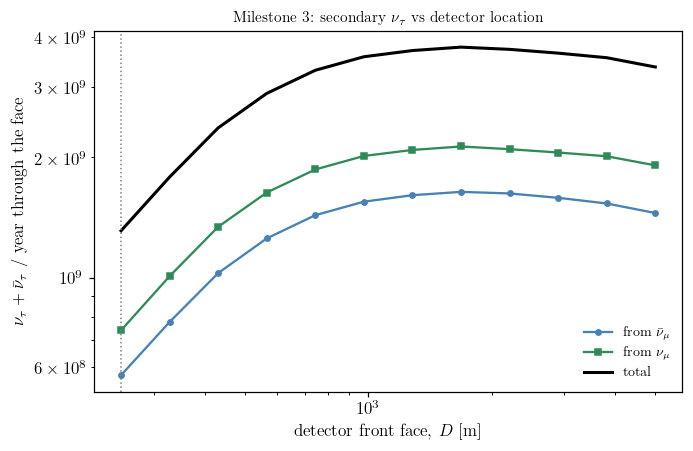

In [16]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(DIST_SCAN/100, nt_scan, "o-", ms=3.5, color="steelblue",
        label=r"from $\bar\nu_\mu$")
ax.plot(DIST_SCAN/100, nt_scan_p, "s-", ms=3.5, color="seagreen",
        label=r"from $\nu_\mu$")
ax.plot(DIST_SCAN/100, nt_scan + nt_scan_p, "k-", lw=2, label="total")
ax.axvline(det.rock_start/100, color="0.5", ls=":", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("detector front face, $D$ [m]")
ax.set_ylabel(r"$\nu_\tau + \bar\nu_\tau$ / year through the face")
ax.set_title("Milestone 3: secondary $\\nu_\\tau$ vs detector location", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
fig.savefig("../plots/beamline_nutau_vs_distance.pdf", bbox_inches="tight", dpi=300)

## 8. Notes and open assumptions

- **Drift-section wall thickness.** MuCol Milestone 15 states that the drift
  beam pipe is surrounded by tungsten but gives no thickness; the quadrupole
  value of 2.53 cm is used. Sec. 3 shows the linear sensitivity.
- **Minimum aperture.** The $5\sigma$ envelope collapses to microns at the
  waists in the long straight, so a 2 cm floor is assumed. This is the single
  most important assumption for the secondary rates: it sets *which* emission
  angles graze along the tungsten wall (Sec. 3).
- **Not modelled**: magnet coils, supports, cold bore, insulation (thin and
  light next to the tungsten), and the detector nozzle inside $|z| < L^* = 6$ m
  (upstream of everything the forward flux traverses).
- The shielding is a **thin tube**, so its contribution is strongly
  ray-dependent. `ray_profile` keeps that per-ray; `flux_weighted_profile`
  averages it, which is exact for rates linear in the column (all production
  rates) but not for the angular distribution of the secondaries.